# 1. Analisi di Serie Storiche su Dati di Ipertensione

## Progetto di Information Systems and Business Intelligence – Fase 2

### Obiettivo

L’obiettivo del notebook è sviluppare una pipeline completa di analisi di serie storiche applicata ai dati di pressione arteriosa.

Il dataset utilizzato contiene misurazioni sanitarie longitudinali raccolte a intervalli regolari per più pazienti. L’analisi si concentrerà principalmente sulla pressione arteriosa sistolica (`BP_Systolic`) di un singolo paziente, selezionato sulla base della completezza e della qualità della serie temporale.

### Struttura del notebook

Il lavoro è organizzato secondo i requisiti previsti dalla consegna:

1. **Caricamento e pre-processing**
   - caricamento del dataset;
   - ispezione della struttura e delle variabili;
   - selezione della serie temporale da analizzare;
   - parsing della variabile temporale;
   - controllo dei duplicati;
   - gestione dei valori mancanti;
   - trattamento delle eventuali anomalie;
   - resampling temporale.

2. **Analisi esplorativa**
   - calcolo delle statistiche descrittive;
   - visualizzazione dell’andamento della pressione arteriosa;
   - analisi della distribuzione dei valori;
   - decomposizione della serie in trend, stagionalità e residuo.

3. **Test statistici**
   - verifica della stazionarietà mediante test ADF;
   - verifica della stazionarietà mediante test KPSS;
   - analisi dell’autocorrelazione tramite ACF;
   - analisi dell’autocorrelazione parziale tramite PACF.

4. **Modellazione predittiva**
   - separazione temporale dei dati in training set e test set;
   - implementazione di almeno due modelli di forecasting;
   - produzione delle previsioni sul periodo di test.

5. **Valutazione**
   - confronto tra valori osservati e valori previsti;
   - calcolo delle metriche MAE, RMSE e MAPE;
   - selezione del modello con le migliori prestazioni.


In [1]:
import pandas as pd

df = pd.read_csv("realistic_synthetic_health_dataset.csv")

print(df.shape)

(5256000, 22)


In [2]:
df.head(20)

,Patient_ID,Timestamp,Age,Gender,Weight,Height,BMI,Heart_Rate,BP_Systolic,BP_Diastolic,...,Body_Temperature,Blood_Glucose,Activity_Level,Sleep_Pattern,Risk_Profile,Hypertension_Label,Anomaly_Type,Is_Anomaly,Data_Quality_Flag,Missing_Mechanism
0,1,2025-01-01 00:00:00,44,Female,63.428666,160.852174,24.514989,64.983253,119.316229,74.359810,...,98.873764,98.147098,3.0,2,moderate_risk,0,none,0,valid,none
1,1,2025-01-01 00:10:00,44,Female,63.440376,160.852174,24.519515,67.370818,120.036205,74.738841,...,98.900441,101.213780,6.0,0,moderate_risk,0,none,0,valid,none
2,1,2025-01-01 00:20:00,44,Female,63.436596,160.852174,24.518054,65.942703,121.965136,75.406949,...,98.892635,102.199192,1.0,2,moderate_risk,0,none,0,valid,none
3,1,2025-01-01 00:30:00,44,Female,63.420567,160.852174,24.511859,65.742632,122.971756,75.722588,...,98.903550,100.494127,1.0,2,moderate_risk,0,none,0,valid,none
4,1,2025-01-01 00:40:00,44,Female,63.404973,160.852174,24.505832,66.055647,122.800885,75.843408,...,98.935292,100.111263,1.0,1,moderate_risk,0,none,0,valid,none
5,1,2025-01-01 00:50:00,44,Female,63.399961,160.852174,24.503895,66.542643,122.373404,76.066659,...,98.939743,103.065297,1.0,1,moderate_risk,0,none,0,valid,none
6,1,2025-01-01 01:00:00,44,Female,63.397914,160.852174,24.503104,66.151005,122.237144,77.099095,...,98.954644,100.868947,3.0,1,moderate_risk,0,none,0,valid,none
7,1,2025-01-01 01:10:00,44,Female,63.397884,160.852174,24.503092,67.080112,122.775256,77.181155,...,98.898566,100.054702,0.0,2,moderate_risk,0,none,0,valid,none
8,1,2025-01-01 01:20:00,44,Female,63.404253,160.852174,24.505554,66.916248,123.692980,77.581665,...,98.893544,100.146862,1.0,1,moderate_risk,0,none,0,valid,none
9,1,2025-01-01 01:30:00,44,Female,63.411248,160.852174,24.508257,65.858149,123.060243,76.528142,...,98.881626,102.188392,1.0,2,moderate_risk,0,none,0,valid,none


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5256000 entries, 0 to 5255999
Data columns (total 22 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Patient_ID          int64  
 1   Timestamp           object 
 2   Age                 int64  
 3   Gender              object 
 4   Weight              float64
 5   Height              float64
 6   BMI                 float64
 7   Heart_Rate          float64
 8   BP_Systolic         float64
 9   BP_Diastolic        float64
 10  SpO2                float64
 11  Respiration_Rate    float64
 12  Body_Temperature    float64
 13  Blood_Glucose       float64
 14  Activity_Level      float64
 15  Sleep_Pattern       int64  
 16  Risk_Profile        object 
 17  Hypertension_Label  int64  
 18  Anomaly_Type        object 
 19  Is_Anomaly          int64  
 20  Data_Quality_Flag   object 
 21  Missing_Mechanism   object 
dtypes: float64(11), int64(5), object(6)
memory usage: 882.2+ MB


### Dataset overview

Prima di procedere con il pre-processing è necessario comprendere la struttura del dataset. In questa sezione vengono analizzate le dimensioni del dataset, il numero di pazienti monitorati, il periodo temporale coperto dalle osservazioni e la distribuzione delle misurazioni per ciascun paziente, così da verificare la completezza delle serie temporali disponibili.

In [4]:
print(f"Shape: ({df.shape[0]:,}, {df.shape[1]})")

print("\nNumero di pazienti:", df["Patient_ID"].nunique()) # quanti pazienti ci sono

print("\nPeriodo:") # quanto dura la serie temporale
print(df["Timestamp"].min())
print(df["Timestamp"].max())

patient_counts = df.groupby("Patient_ID").size() # # quante osservazioni ha ogni paziente

print("\nOsservazioni per paziente:")
print(patient_counts.describe())

print("\nDistribuzione osservazioni:")
print(patient_counts.sort_values().head())
print(patient_counts.sort_values().tail())

Shape: (5,256,000, 22)

Numero di pazienti: 100

Periodo:
2025-01-01 00:00:00
2025-12-31 23:50:00

Osservazioni per paziente:
count      100.0
mean     52560.0
std          0.0
min      52560.0
25%      52560.0
50%      52560.0
75%      52560.0
max      52560.0
dtype: float64

Distribuzione osservazioni:
Patient_ID
1    52560
2    52560
3    52560
4    52560
5    52560
dtype: int64
Patient_ID
96     52560
97     52560
98     52560
99     52560
100    52560
dtype: int64


#### Interpretazione

L'analisi mostra che il dataset è costituito da **5.256.000 osservazioni** e **22 variabili**, riferite a **100 pazienti**. Tutti i pazienti dispongono di una serie temporale completa composta da **52.560 osservazioni**, corrispondenti a misurazioni effettuate ogni 10 minuti nell'arco di un anno (dal 1° gennaio 2025 al 31 dicembre 2025). La struttura omogenea del dataset consente di selezionare un singolo paziente senza introdurre differenze dovute alla lunghezza della serie temporale.

# 2. Data Pre-processing

Prima di procedere con l'analisi delle serie temporali è necessario effettuare il pre-processing del dataset.

Questa fase comprende tutte le operazioni necessarie per ottenere una serie temporale corretta e pronta per la modellazione, tra cui:

- conversione della variabile temporale (`Timestamp`);
- ordinamento cronologico delle osservazioni;
- verifica della presenza di timestamp duplicati;
- controllo della frequenza di campionamento;
- analisi dei valori mancanti;
- verifica della presenza di anomalie;
- selezione del paziente oggetto dell'analisi;
- eventuale resampling temporale.

L'obiettivo è costruire una serie temporale continua e coerente sulla quale applicare i modelli di forecasting previsti dal progetto.

### Parsing della variabile temporale

La variabile `Timestamp` viene convertita dal formato stringa (`object`) al formato `datetime`, così da consentire le successive operazioni di indicizzazione temporale, ordinamento cronologico e resampling.

In [5]:
# Conversione del Timestamp in formato datetime

df["Timestamp"] = pd.to_datetime(df["Timestamp"])

print(df["Timestamp"].dtype)

datetime64[ns]


### Ordinamento cronologico

Successivamente il dataset viene ordinato in base al paziente e all'istante temporale della rilevazione, così da garantire che ogni serie temporale sia perfettamente ordinata.

In [6]:
df = df.sort_values(
    by=["Patient_ID", "Timestamp"]
).reset_index(drop=True)

df.head()

,Patient_ID,Timestamp,Age,Gender,Weight,Height,BMI,Heart_Rate,BP_Systolic,BP_Diastolic,...,Body_Temperature,Blood_Glucose,Activity_Level,Sleep_Pattern,Risk_Profile,Hypertension_Label,Anomaly_Type,Is_Anomaly,Data_Quality_Flag,Missing_Mechanism
0,1,2025-01-01 00:00:00,44,Female,63.428666,160.852174,24.514989,64.983253,119.316229,74.359810,...,98.873764,98.147098,3.0,2,moderate_risk,0,none,0,valid,none
1,1,2025-01-01 00:10:00,44,Female,63.440376,160.852174,24.519515,67.370818,120.036205,74.738841,...,98.900441,101.213780,6.0,0,moderate_risk,0,none,0,valid,none
2,1,2025-01-01 00:20:00,44,Female,63.436596,160.852174,24.518054,65.942703,121.965136,75.406949,...,98.892635,102.199192,1.0,2,moderate_risk,0,none,0,valid,none
3,1,2025-01-01 00:30:00,44,Female,63.420567,160.852174,24.511859,65.742632,122.971756,75.722588,...,98.903550,100.494127,1.0,2,moderate_risk,0,none,0,valid,none
4,1,2025-01-01 00:40:00,44,Female,63.404973,160.852174,24.505832,66.055647,122.800885,75.843408,...,98.935292,100.111263,1.0,1,moderate_risk,0,none,0,valid,none


### Verifica dei timestamp duplicati

Per ogni paziente viene verificata l'eventuale presenza di osservazioni duplicate riferite allo stesso istante temporale. La presenza di duplicati potrebbe compromettere la qualità della serie temporale e alterare le successive analisi statistiche.

In [7]:
duplicates = df.duplicated(
    subset=["Patient_ID", "Timestamp"]
).sum()

print(f"Duplicati trovati: {duplicates}")

Duplicati trovati: 0


### Verifica della frequenza di campionamento

La documentazione del dataset indica che le misurazioni vengono effettuate ogni 10 minuti. Tale informazione viene verificata calcolando la differenza temporale tra due osservazioni consecutive appartenenti allo stesso paziente.

In [8]:
patient1 = df[df["Patient_ID"] == 1].copy()

time_diff = patient1["Timestamp"].diff().value_counts()

time_diff.head()

,count
Timestamp,
0 days 00:10:00,52559


### Analisi dei valori mancanti

Prima di procedere con la selezione del paziente e con la modellazione, è necessario verificare la presenza di valori mancanti all'interno del dataset.

L'analisi viene effettuata calcolando, per ogni variabile, il numero e la percentuale di valori nulli. Questo controllo permette di individuare eventuali criticità che potrebbero influenzare le successive fasi di analisi e di forecasting.

In [9]:
# Conteggio dei valori mancanti per ogni variabile

missing_values = df.isnull().sum()

missing_percentage = (
    missing_values / len(df) * 100
)

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": missing_percentage
})

missing_summary = missing_summary.sort_values(
    by="Missing Values",
    ascending=False
)

missing_summary

,Missing Values,Percentage (%)
SpO2,259248,4.93242
Heart_Rate,259248,4.93242
Respiration_Rate,259248,4.93242
Age,0,0.00000
Patient_ID,0,0.00000
Timestamp,0,0.00000
Height,0,0.00000
Weight,0,0.00000
Gender,0,0.00000
BMI,0,0.00000


### Interpretazione dei valori mancanti

L'analisi evidenzia la presenza di valori mancanti esclusivamente nelle variabili **Heart_Rate**, **SpO₂** e **Respiration_Rate**, ciascuna con **259.248 osservazioni mancanti**, pari al **4,93%** del dataset.

Tutte le altre variabili, inclusa **BP_Systolic**, che rappresenta la variabile target del progetto, risultano complete e prive di valori nulli.

Poiché la variabile target del progetto (BP_Systolic) non presenta valori mancanti, la presenza di valori nulli nelle sole variabili ausiliarie non compromette l'analisi della serie temporale principale. La strategia adottata per la loro gestione verrà definita dopo la selezione delle variabili effettivamente utilizzate nella modellazione.

### Analisi della qualità del dato

Per interpretare correttamente la presenza dei valori mancanti è stata analizzata anche la documentazione fornita dal dataset attraverso le variabili **Data_Quality_Flag** e **Missing_Mechanism**, introdotte dagli autori per descrivere la qualità delle osservazioni e il meccanismo di generazione dei dati mancanti.

**Data_Quality_Flag** → indica se una rilevazione è valida (valid), mancante (missing) oppure affetta da un errore del sensore (sensor_error).

**Missing_Mechanism**→ spiega il motivo della mancanza del dato:

activity_related_dropout: perdita della misurazione dovuta all'attività del paziente (ad esempio movimento del dispositivo);
burst_dropout: perdita temporanea di una sequenza di misurazioni;
none: nessun problema.

In [10]:
print("Data Quality Flag")
print(df["Data_Quality_Flag"].value_counts())

print("\nMissing Mechanism")
print(df["Missing_Mechanism"].value_counts())

Data Quality Flag
Data_Quality_Flag
valid           4992752
missing          259248
sensor_error       4000
Name: count, dtype: int64

Missing Mechanism
Missing_Mechanism
none                           4996752
activity_correlated_dropout     228337
burst_dropout                    30911
Name: count, dtype: int64


L'analisi mostra che la maggior parte delle rilevazioni è classificata come **valid**, mentre una parte delle osservazioni è etichettata come **missing** oppure come **sensor_error**.

La variabile **Missing_Mechanism** indica inoltre che i valori mancanti sono stati simulati secondo meccanismi realistici, distinguendo tra perdite dovute all'attività del paziente (*activity_related_dropout*) e interruzioni temporanee della trasmissione dei dati (*burst_dropout*).

Queste informazioni confermano che i dati mancanti sono stati introdotti in modo controllato e documentato, rappresentando scenari tipici dei sistemi di monitoraggio sanitario basati su dispositivi wearable.

# 3. Selezione della serie temporale

Il dataset è costituito da 100 pazienti, ciascuno monitorato con una frequenza di una rilevazione ogni 10 minuti per l'intero anno 2025.

Poiché l'obiettivo del progetto è sviluppare e confrontare modelli di previsione per una serie temporale univariata, è necessario selezionare una singola serie temporale continua.

L'analisi preliminare ha evidenziato che tutti i pazienti presentano la stessa struttura temporale, lo stesso numero di osservazioni (52.560) e la medesima frequenza di campionamento. Pertanto, la scelta del paziente non influenza la qualità della modellazione.

Per garantire la riproducibilità dell'analisi viene selezionato il paziente con **Patient_ID = 1**, adottando un criterio deterministico e facilmente replicabile.

È possibile che altri pazienti presentino caratteristiche cliniche differenti, come età più avanzata o profili di rischio cardiovascolare più elevati, che potrebbero determinare una dinamica pressoria più variabile o complessa. Tuttavia, l'obiettivo del presente lavoro non è confrontare diversi pazienti, bensì sviluppare e valutare una metodologia di forecasting applicata a una singola serie temporale. Un'eventuale estensione futura potrebbe prevedere il confronto delle prestazioni dei modelli su soggetti con differenti caratteristiche cliniche.

In [11]:
# Selezione del paziente

patient = df[df["Patient_ID"] == 1].copy()

# Salvataggio del paziente in un nuovo CSV che mi servirà dopo con Streamlit
patient.to_csv(
    "patient_1_dataset.csv",
    index=False
)

print("Shape:", patient.shape)

patient.head()

Shape: (52560, 22)


,Patient_ID,Timestamp,Age,Gender,Weight,Height,BMI,Heart_Rate,BP_Systolic,BP_Diastolic,...,Body_Temperature,Blood_Glucose,Activity_Level,Sleep_Pattern,Risk_Profile,Hypertension_Label,Anomaly_Type,Is_Anomaly,Data_Quality_Flag,Missing_Mechanism
0,1,2025-01-01 00:00:00,44,Female,63.428666,160.852174,24.514989,64.983253,119.316229,74.359810,...,98.873764,98.147098,3.0,2,moderate_risk,0,none,0,valid,none
1,1,2025-01-01 00:10:00,44,Female,63.440376,160.852174,24.519515,67.370818,120.036205,74.738841,...,98.900441,101.213780,6.0,0,moderate_risk,0,none,0,valid,none
2,1,2025-01-01 00:20:00,44,Female,63.436596,160.852174,24.518054,65.942703,121.965136,75.406949,...,98.892635,102.199192,1.0,2,moderate_risk,0,none,0,valid,none
3,1,2025-01-01 00:30:00,44,Female,63.420567,160.852174,24.511859,65.742632,122.971756,75.722588,...,98.903550,100.494127,1.0,2,moderate_risk,0,none,0,valid,none
4,1,2025-01-01 00:40:00,44,Female,63.404973,160.852174,24.505832,66.055647,122.800885,75.843408,...,98.935292,100.111263,1.0,1,moderate_risk,0,none,0,valid,none


### Scelta progettuale per l'applicazione Streamlit

Durante la fase di sviluppo dell'applicazione Streamlit è emersa una criticità legata alle dimensioni del dataset originale. Il file **realistic_synthetic_health_dataset.csv**, contenente oltre **5,2 milioni** di osservazioni relative a 100 pazienti, risultava troppo pesante per garantire tempi di caricamento e prestazioni adeguate nell'ambiente di deploy di Streamlit Community Cloud.

Poiché l'intera analisi statistica della Fase 2 è stata sviluppata esclusivamente sul Patient_ID = 1, è stato creato un file CSV (**patient_1_dataset.csv**) contenente unicamente le osservazioni di tale paziente. Questa scelta non modifica la metodologia dell'analisi né i risultati ottenuti, ma rappresenta una soluzione progettuale finalizzata a migliorare l'efficienza dell'applicazione e a garantire un'esperienza d'uso fluida.

In [12]:
# controllo del periodo
print(patient["Timestamp"].min())
print(patient["Timestamp"].max())

2025-01-01 00:00:00
2025-12-31 23:50:00


In [13]:
# impostazione indice temporale
patient = patient.set_index("Timestamp")

patient.head()

,Patient_ID,Age,Gender,Weight,Height,BMI,Heart_Rate,BP_Systolic,BP_Diastolic,SpO2,...,Body_Temperature,Blood_Glucose,Activity_Level,Sleep_Pattern,Risk_Profile,Hypertension_Label,Anomaly_Type,Is_Anomaly,Data_Quality_Flag,Missing_Mechanism
Timestamp,,,,,,,,,,,,,,,,,,,,,
2025-01-01 00:00:00,1,44,Female,63.428666,160.852174,24.514989,64.983253,119.316229,74.359810,96.255476,...,98.873764,98.147098,3.0,2,moderate_risk,0,none,0,valid,none
2025-01-01 00:10:00,1,44,Female,63.440376,160.852174,24.519515,67.370818,120.036205,74.738841,96.251179,...,98.900441,101.213780,6.0,0,moderate_risk,0,none,0,valid,none
2025-01-01 00:20:00,1,44,Female,63.436596,160.852174,24.518054,65.942703,121.965136,75.406949,96.284318,...,98.892635,102.199192,1.0,2,moderate_risk,0,none,0,valid,none
2025-01-01 00:30:00,1,44,Female,63.420567,160.852174,24.511859,65.742632,122.971756,75.722588,96.539722,...,98.903550,100.494127,1.0,2,moderate_risk,0,none,0,valid,none
2025-01-01 00:40:00,1,44,Female,63.404973,160.852174,24.505832,66.055647,122.800885,75.843408,96.311951,...,98.935292,100.111263,1.0,1,moderate_risk,0,none,0,valid,none


In [14]:
print(patient.index.is_monotonic_increasing)

True


# 4. Analisi esplorativa dei dati (EDA)

Dopo aver selezionato il paziente oggetto dell'analisi, viene effettuata un'esplorazione preliminare della serie temporale.

Questa fase ha l'obiettivo di descrivere statisticamente la variabile di interesse, visualizzarne l'andamento nel tempo e individuare eventuali trend, variazioni di livello o comportamenti periodici che potranno essere approfonditi nelle fasi successive mediante la decomposizione della serie e i test di stazionarietà.

## 4.1 Statistiche descrittive

L'analisi descrittiva della pressione arteriosa sistolica permette di ottenere una prima caratterizzazione della distribuzione della serie temporale attraverso indicatori sintetici quali media, deviazione standard, valori minimo e massimo e quartili.

In [15]:
summary = patient["BP_Systolic"].describe().to_frame()

summary

,BP_Systolic
count,52560.000000
mean,126.947648
std,3.805330
min,112.757833
25%,124.451464
50%,126.990118
75%,129.407830
max,157.862515


### Interpretazione

La pressione arteriosa sistolica presenta una media pari a circa **126,95 mmHg**, con una deviazione standard di **3,81 mmHg**, indicando una variabilità contenuta nel corso del monitoraggio.

Il valore minimo osservato è pari a **112,76 mmHg**, mentre il massimo raggiunge **157,86 mmHg**, suggerendo la presenza di alcuni episodi pressori elevati rispetto ai valori medi.

I quartili mostrano che il 50% delle osservazioni è compreso tra **124,45 mmHg** e **129,41 mmHg**, evidenziando una distribuzione piuttosto concentrata attorno al valore centrale.

## 4.2 Andamento temporale della pressione arteriosa sistolica

Viene rappresentato graficamente l'andamento della pressione arteriosa sistolica durante l'intero periodo di monitoraggio.

L'obiettivo è verificare visivamente la presenza di eventuali trend, oscillazioni periodiche, variazioni della variabilità o anomalie evidenti.

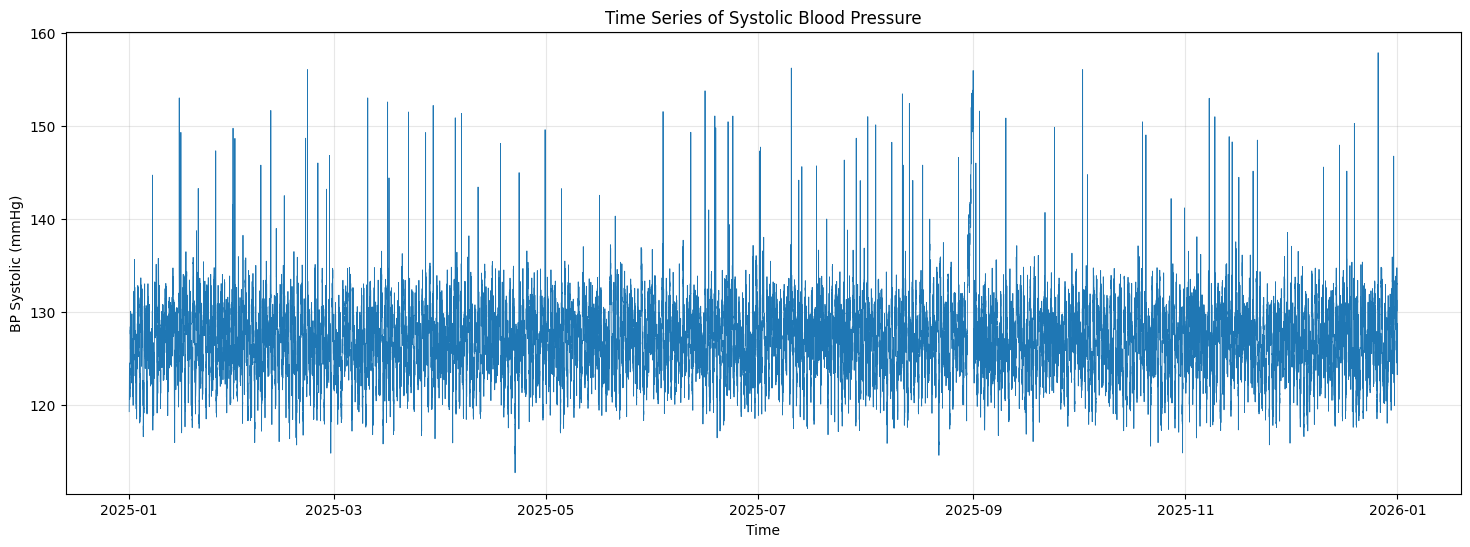

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18,6))

plt.plot(
    patient.index,
    patient["BP_Systolic"],
    linewidth=0.6
)

plt.title("Time Series of Systolic Blood Pressure")
plt.xlabel("Time")
plt.ylabel("BP Systolic (mmHg)")

plt.grid(alpha=0.3)

plt.show()

### Interpretazione

La serie temporale non evidenzia un trend crescente o decrescente nel corso dell'anno di osservazione.

La pressione sistolica oscilla attorno ad un livello medio pressoché costante, mostrando una variabilità relativamente stabile e alcuni picchi isolati di maggiore intensità.

L'assenza di cambiamenti strutturali evidenti suggerisce una serie temporalmente stabile, la cui eventuale componente stagionale verrà approfondita nella fase successiva mediante decomposizione.

## 4.3 Distribuzione della pressione arteriosa sistolica

Oltre all'andamento temporale, viene analizzata la distribuzione della variabile mediante istogramma, così da verificare la presenza di eventuali asimmetrie, valori estremi o distribuzioni multimodali.

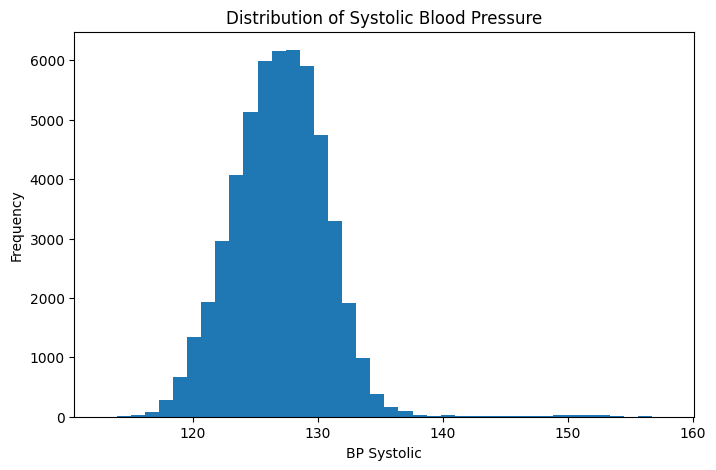

In [17]:
plt.figure(figsize=(8,5))

plt.hist(
    patient["BP_Systolic"],
    bins=40
)

plt.title("Distribution of Systolic Blood Pressure")

plt.xlabel("BP Systolic")

plt.ylabel("Frequency")

plt.show()

### Interpretazione

L'istogramma evidenzia una distribuzione approssimativamente unimodale e prossima alla normale, centrata intorno ai 127 mmHg.

Si osserva una lieve asimmetria verso destra dovuta alla presenza di alcuni episodi pressori particolarmente elevati, coerenti con eventi fisiologici simulati dal dataset.

Nel complesso la distribuzione risulta compatibile con una serie fisiologica continua, rendendo appropriata l'applicazione dei successivi modelli di serie temporali.

# 5. Resampling temporale

Il dataset originale presenta una frequenza di campionamento pari a una rilevazione ogni **10 minuti**.

Sebbene questa frequenza sia già regolare e completa, viene effettuato un resampling temporale per ottenere una serie a frequenza oraria.

Questa operazione consente di ridurre la variabilità di breve periodo, semplificare l'analisi grafica e confrontare differenti granularità temporali, mantenendo inalterato il comportamento generale della serie.

In [18]:
# Resampling orario della pressione sistolica

ts = patient["BP_Systolic"].resample("h").mean()

ts.head()

,BP_Systolic
Timestamp,
2025-01-01 00:00:00,121.577269
2025-01-01 01:00:00,123.345429
2025-01-01 02:00:00,123.458882
2025-01-01 03:00:00,121.879436
2025-01-01 04:00:00,122.219606


In [19]:
print("Numero osservazioni originali:", len(patient))
print("Numero osservazioni orarie:", len(ts))
print("Valori mancanti:", ts.isna().sum())

Numero osservazioni originali: 52560
Numero osservazioni orarie: 8760
Valori mancanti: 0


### Interpretazione

Il resampling riduce il numero di osservazioni da 52.560 a 8.760, sostituendo le sei rilevazioni effettuate ogni ora con il loro valore medio.
La serie risultante mantiene la struttura temporale originale, ma risulta meno rumorosa e più facilmente interpretabile; sarà utilizzata nelle successive fasi di decomposizione, nei test di stazionarietà e nella modellazione predittiva.

### Visualizzazione della serie temporale dopo il resampling

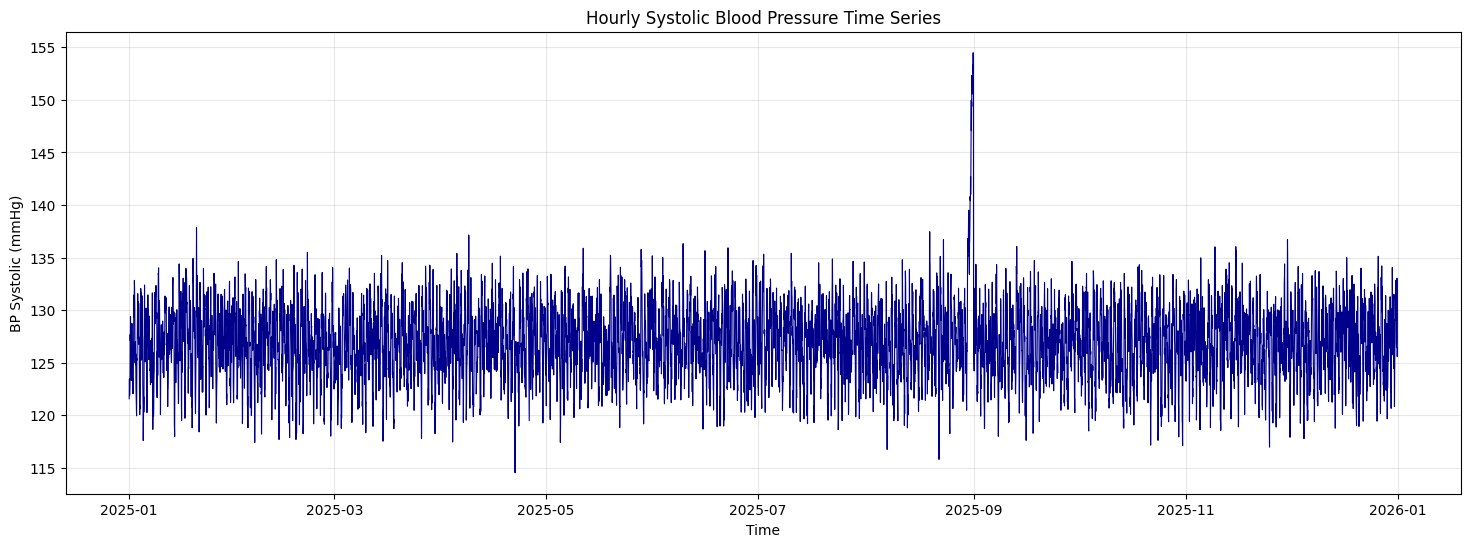

In [20]:
plt.figure(figsize=(18,6))

plt.plot(
    ts.index,
    ts,
    linewidth=0.8,
    color="darkblue"
)

plt.title("Hourly Systolic Blood Pressure Time Series")

plt.xlabel("Time")

plt.ylabel("BP Systolic (mmHg)")

plt.grid(alpha=0.3)

plt.show()

### Interpretazione

Il grafico della serie oraria evidenzia un andamento complessivamente stabile della pressione arteriosa sistolica durante l'intero periodo di osservazione.

L'aggregazione oraria riduce la variabilità dovuta alle misurazioni effettuate ogni 10 minuti, rendendo più leggibili le oscillazioni della serie senza alterarne la struttura temporale.

Non si osservano evidenti trend di lungo periodo, mentre risultano presenti oscillazioni ricorrenti e alcuni picchi isolati di maggiore intensità, che saranno analizzati nelle successive fasi di decomposizione della serie e mediante i test di stazionarietà.

### Analisi del profilo giornaliero

Prima di procedere con la decomposizione della serie temporale viene analizzato il profilo medio giornaliero della pressione arteriosa sistolica.

Per ogni ora della giornata è stata calcolata la media delle osservazioni disponibili durante l'intero anno di monitoraggio.

Questa analisi permette di verificare la presenza di un ritmo circadiano, caratteristico dei parametri fisiologici, e di giustificare la scelta di utilizzare un periodo stagionale pari a 24 osservazioni nella successiva decomposizione.

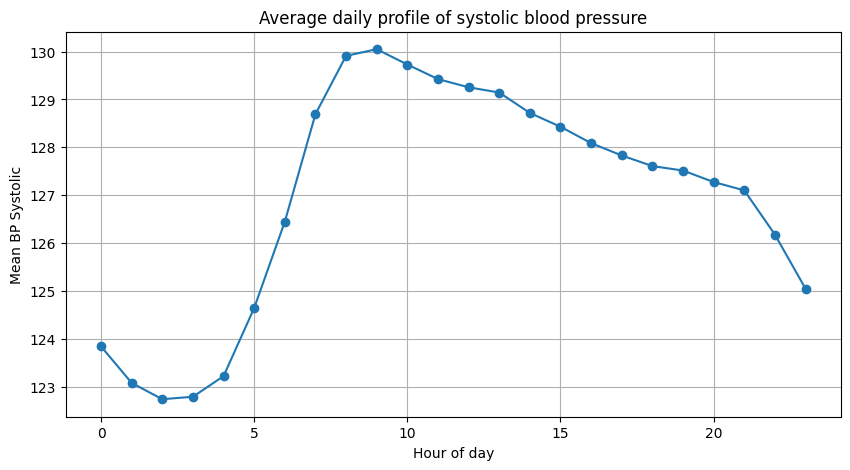

In [21]:
hourly_profile = (
    patient
    .groupby(patient.index.hour)["BP_Systolic"]
    .mean()
)

plt.figure(figsize=(10,5))
plt.plot(hourly_profile.index, hourly_profile.values, marker="o")
plt.xlabel("Hour of day")
plt.ylabel("Mean BP Systolic")
plt.title("Average daily profile of systolic blood pressure")
plt.grid(True)
plt.show()

### Interpretazione

Il grafico evidenzia un chiaro andamento circadiano della pressione arteriosa sistolica.

I valori medi risultano più bassi durante le ore notturne, raggiungendo il minimo tra le 2:00 e le 4:00 del mattino. Successivamente la pressione aumenta progressivamente nelle prime ore della giornata, raggiungendo il valore massimo intorno alle 9:00.

Nel corso del pomeriggio e della sera si osserva una graduale diminuzione fino al ritorno ai livelli notturni.

Questo comportamento conferma la presenza di una componente stagionale giornaliera nella serie temporale e giustifica l'utilizzo di un periodo pari a 24 osservazioni nella successiva decomposizione.

# 6. Decomposizione della serie temporale

Una serie temporale può essere interpretata come la combinazione di diverse componenti fondamentali.

La decomposizione consente di separare la serie nelle sue componenti principali:

- **Trend**, che descrive l'andamento di lungo periodo;
- **Stagionalità**, che rappresenta eventuali pattern periodici ricorrenti;
- **Residuo**, che contiene la variabilità non spiegata dalle componenti precedenti.

Questa analisi permette di comprendere meglio la struttura della serie prima dell'applicazione dei test di stazionarietà e dei modelli di forecasting.

Per analizzare separatamente le componenti della serie temporale è stata applicata una decomposizione additiva utilizzando la serie oraria della pressione arteriosa sistolica.

Poiché la serie contiene 8.760 osservazioni (una per ogni ora dell'anno), la visualizzazione simultanea di tutte le componenti tramite il grafico standard della decomposizione risulta poco leggibile. Per questo motivo si è scelto di rappresentare separatamente le componenti di trend, stagionalità e residuo, così da facilitarne l'interpretazione.

La periodicità è stata impostata pari a **24 osservazioni**, corrispondenti al ciclo giornaliero evidenziato durante l'analisi esplorativa.

In [22]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    ts,
    model="additive",
    period=24
)

### 6.1 Componente di trend

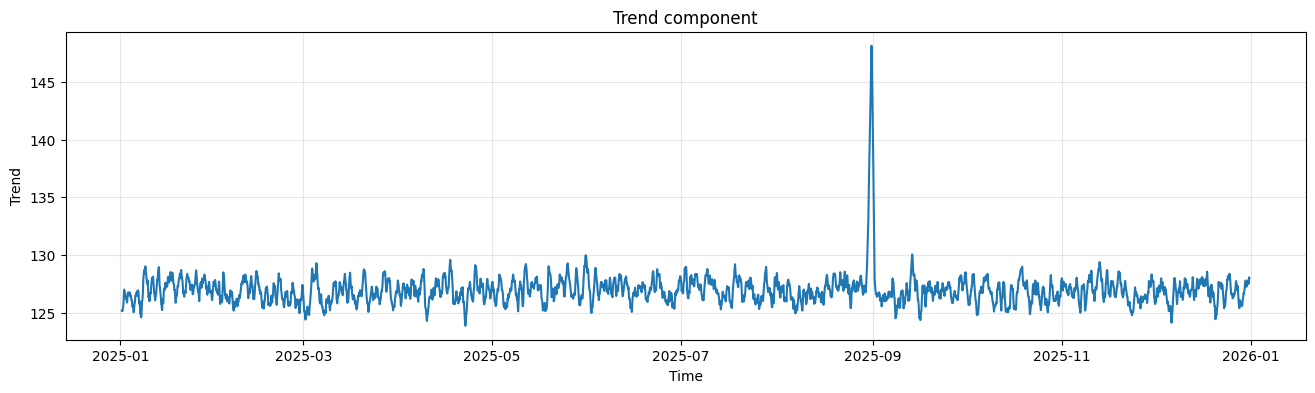

In [23]:
plt.figure(figsize=(16,4))

plt.plot(decomposition.trend)

plt.title("Trend component")

plt.xlabel("Time")

plt.ylabel("Trend")

plt.grid(alpha=0.3)

plt.show()

La componente di trend rappresenta l'andamento di fondo della pressione arteriosa sistolica nel corso dell'anno, depurato dalle oscillazioni giornaliere.

Dall'analisi emerge un andamento sostanzialmente stabile, senza una crescita o una diminuzione progressiva della pressione nel lungo periodo. È tuttavia presente un marcato picco isolato intorno ai primi giorni di settembre, riconducibile a un evento anomalo presente nel dataset.

Nel complesso, il dataset non evidenzia un trend strutturale significativo, suggerendo che la variabilità della serie sia principalmente spiegata dalla componente stagionale e dalle fluttuazioni casuali.

### 6.2 Componente stagionale
#### Visualizzazione della componente stagionale

La decomposizione è stata calcolata sull'intera serie temporale, composta da **8.760 osservazioni orarie** relative ai 365 giorni dell'anno.

Impostando `period=24`, il metodo assume la presenza di un pattern che si ripete ogni 24 osservazioni, corrispondenti a un ciclo giornaliero. La componente stagionale viene quindi stimata utilizzando tutti i giorni disponibili nel dataset, confrontando il comportamento della pressione nelle medesime ore della giornata.

Il grafico mostra soltanto le prime 24 osservazioni della componente stagionale, cioè un singolo ciclo completo. Questo non rappresenta l'andamento di uno specifico giorno, ma il **profilo stagionale giornaliero stimato sulla base dell'intero anno di osservazioni**.

Visualizzare la componente per tutte le 8.760 ore significherebbe rappresentare lo stesso ciclo giornaliero ripetuto 365 volte, producendo un grafico poco leggibile. Per questo motivo viene mostrato un solo ciclo di 24 ore, sufficiente a descrivere il pattern periodico che si ripete quotidianamente.

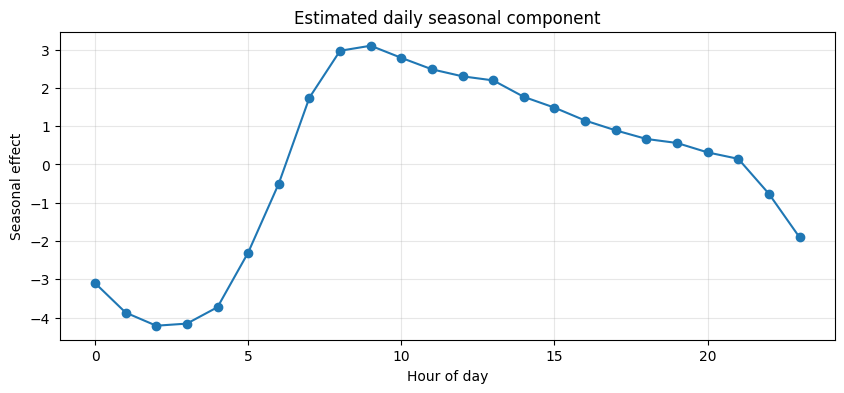

In [24]:
seasonal_pattern = decomposition.seasonal.iloc[:24]

plt.figure(figsize=(10,4))

plt.plot(
    seasonal_pattern.index.hour,
    seasonal_pattern.values,
    marker="o"
)

plt.title("Estimated daily seasonal component")

plt.xlabel("Hour of day")

plt.ylabel("Seasonal effect")

plt.grid(alpha=0.3)

plt.show()

La componente stagionale descrive la variazione sistematica della pressione arteriosa che si ripete nell'arco delle 24 ore.

Il profilo stimato dalla decomposizione conferma quanto osservato nell'analisi del profilo medio giornaliero: la pressione risulta mediamente più bassa durante le ore notturne, aumenta rapidamente nelle prime ore del mattino, raggiunge il valore massimo nella fascia mattutina e diminuisce progressivamente nel corso della giornata.

La componente stagionale conferma la presenza di un ritmo circadiano nella pressione arteriosa sistolica.

L'effetto stagionale risulta negativo durante le ore notturne, indicando valori inferiori rispetto al livello medio della serie. Nelle prime ore del mattino la componente aumenta rapidamente e raggiunge il massimo nella fascia mattutina, per poi diminuire gradualmente nel corso del pomeriggio e della sera.

Il profilo è molto simile a quello ottenuto mediante il calcolo della pressione media per ora del giorno. I due grafici descrivono infatti lo stesso fenomeno con metodi differenti.
Il profilo medio giornaliero è ottenuto calcolando direttamente la media della pressione arteriosa per ciascuna ora del giorno sull'intero periodo di osservazione e costituisce un'analisi puramente descrittiva.

La componente stagionale, invece, è stimata mediante la decomposizione della serie temporale dopo aver separato il trend e il residuo. Essa rappresenta quindi il pattern periodico che il modello considera sistematicamente ripetuto nel tempo.

Nel dataset analizzato le due rappresentazioni risultano quasi sovrapponibili, poiché il trend è sostanzialmente stabile e la componente stagionale costituisce la principale fonte di variabilità della serie.

### 6.3 Componente residua

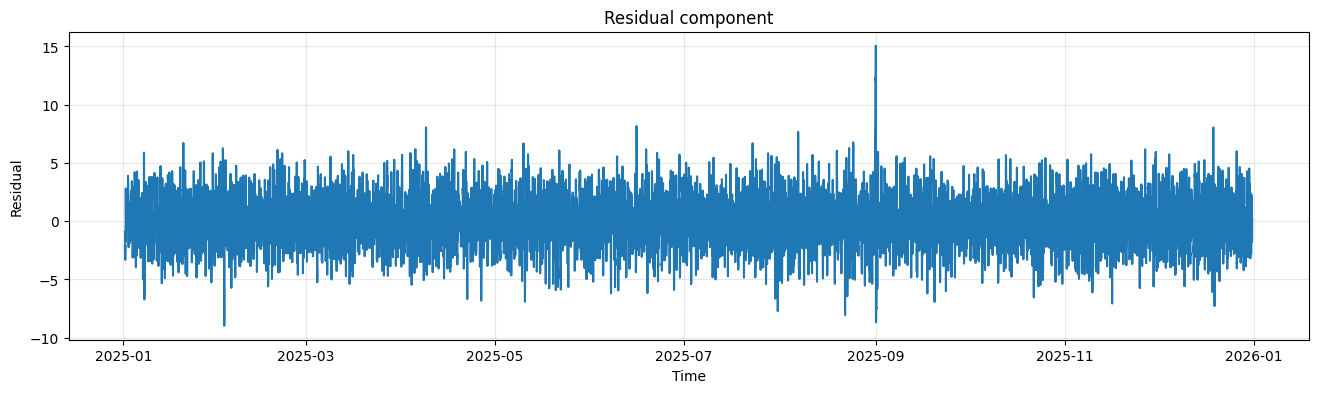

In [25]:
plt.figure(figsize=(16,4))

plt.plot(decomposition.resid)

plt.title("Residual component")

plt.xlabel("Time")

plt.ylabel("Residual")

plt.grid(alpha=0.3)

plt.show()

La componente residua rappresenta la parte della serie che non viene spiegata né dal trend né dalla stagionalità.

I residui risultano distribuiti intorno allo zero, senza evidenti pattern sistematici, indicando che la decomposizione ha catturato correttamente le principali componenti della serie.

Sono comunque presenti alcuni picchi isolati, coerenti con eventi anomali simulati nel dataset, che rappresentano variazioni improvvise non spiegabili attraverso il normale andamento temporale.

### Conclusioni della decomposizione

L'analisi della decomposizione evidenzia la presenza di una chiara componente stagionale giornaliera nella serie temporale della pressione arteriosa sistolica.

Il pattern osservato è coerente con il profilo medio giornaliero analizzato nella fase esplorativa: la pressione tende ad assumere valori più bassi durante la notte, aumenta progressivamente nelle prime ore del mattino, raggiunge un massimo nella fascia mattutina e diminuisce gradualmente nel resto della giornata.

La presenza di questo comportamento periodico conferma l'esistenza di un ritmo circadiano nella serie temporale e giustifica la scelta di utilizzare un periodo pari a 24 osservazioni nella decomposizione.

Nella fase successiva verrà verificato se la serie soddisfa anche il requisito della stazionarietà mediante i test statistici ADF e KPSS, condizione fondamentale per la modellazione predittiva.

# 7. Analisi della stazionarietà

Prima di costruire un modello di forecasting è necessario verificare se la serie temporale è stazionaria.

Una serie stazionaria mantiene nel tempo media, varianza e struttura di autocorrelazione sostanzialmente costanti.

Per questo motivo verranno applicati due test complementari:

- Augmented Dickey-Fuller (ADF)
- KPSS (Kwiatkowski-Phillips-Schmidt-Shin)

L'utilizzo congiunto dei due test permette di ottenere una valutazione più robusta della stazionarietà della serie.

In [26]:
# test ADF
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(ts)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print()

print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -14.887397785618568
p-value: 1.575943824197148e-27

Critical Values:
1%: -3.431099968539641
5%: -2.86187143613454
10%: -2.5669464184887825


### Interpretazione del test ADF

Il test Augmented Dickey-Fuller verifica la presenza di una radice unitaria.

- **Ipotesi nulla (H0):** la serie non è stazionaria.
- **Ipotesi alternativa (H1):** la serie è stazionaria.

Un **p-value inferiore a 0.05** consente di rifiutare l'ipotesi nulla e concludere che la serie può essere considerata stazionaria.

In [27]:
# test KPSS
from statsmodels.tsa.stattools import kpss

kpss_result = kpss(ts)

print("KPSS Statistic:", kpss_result[0])
print("p-value:", kpss_result[1])

print("\nCritical Values:")
for key, value in kpss_result[3].items():
    print(f"{key}: {value}")

KPSS Statistic: 0.1216599407707503
p-value: 0.1

Critical Values:
10%: 0.347
5%: 0.463
2.5%: 0.574
1%: 0.739


/tmp/ipykernel_11021/4286322394.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(ts)


### Interpretazione del test KPSS

Il test KPSS utilizza un'impostazione complementare rispetto all'ADF.

- **Ipotesi nulla (H0):** la serie è stazionaria.
- **Ipotesi alternativa (H1):** la serie non è stazionaria.

In questo caso un **p-value maggiore di 0.05** indica che non vi sono evidenze sufficienti per rifiutare la stazionarietà della serie.

### Conclusioni sulla stazionarietà

I risultati dei due test statistici sono coerenti tra loro.

Il test **Augmented Dickey-Fuller (ADF)** restituisce un p-value estremamente inferiore alla soglia di significatività del 5%, consentendo di rifiutare l'ipotesi nulla di presenza di una radice unitaria e concludere che la serie è stazionaria.

Il test **KPSS**, che utilizza un'ipotesi nulla opposta, restituisce invece un p-value pari a 0.10. Poiché tale valore è superiore al livello di significatività del 5%, non vi sono evidenze sufficienti per rifiutare l'ipotesi di stazionarietà.

L'accordo tra i due test fornisce una forte evidenza statistica che la serie della pressione arteriosa sistolica possa essere considerata stazionaria.

Di conseguenza, non risulta necessario applicare trasformazioni preliminari, come differenziazione o rimozione del trend, prima della fase di modellazione.

# 8. Analisi dell'autocorrelazione

Dopo aver verificato che la serie è stazionaria, si analizza la struttura di autocorrelazione della pressione arteriosa sistolica.

L'autocorrelazione misura il grado di dipendenza tra il valore osservato in un determinato istante e i valori osservati nei periodi precedenti.

Per questo scopo vengono utilizzati:

- **ACF (Autocorrelation Function)**, che misura la correlazione tra la serie e le sue versioni ritardate (lag);
- **PACF (Partial Autocorrelation Function)**, che misura la correlazione diretta tra due osservazioni eliminando l'effetto dei lag intermedi.

Queste analisi sono fondamentali per individuare la struttura temporale della serie e guidare la scelta del modello di forecasting.

<Figure size 1200x500 with 0 Axes>

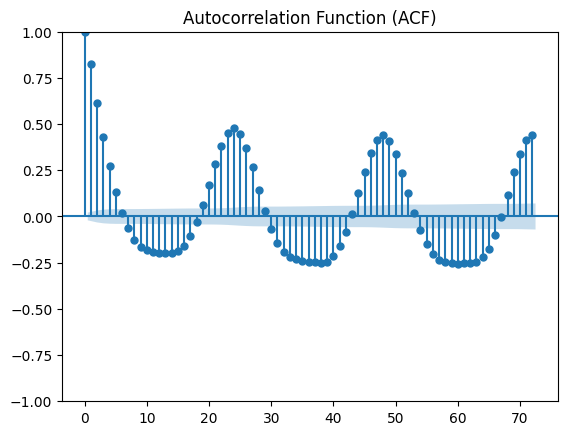

In [28]:
# ACF
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plot_acf(
    ts,
    lags=72,
    alpha=0.05
)

plt.title("Autocorrelation Function (ACF)")
plt.show()

### Interpretazione dell'ACF

L'Autocorrelation Function evidenzia una forte correlazione positiva ai primi lag, indicando che la pressione arteriosa sistolica mantiene una marcata dipendenza dai valori osservati nelle ore immediatamente precedenti.

L'autocorrelazione decresce progressivamente con l'aumentare del ritardo temporale, ma mostra nuovi picchi significativi in corrispondenza dei lag 24, 48 e 72.

Poiché la serie è stata ricampionata con frequenza oraria, tali lag corrispondono rispettivamente a uno, due e tre giorni. Questo comportamento conferma quantitativamente la presenza della componente stagionale giornaliera già osservata durante l'analisi esplorativa e nella decomposizione della serie.

<Figure size 1200x500 with 0 Axes>

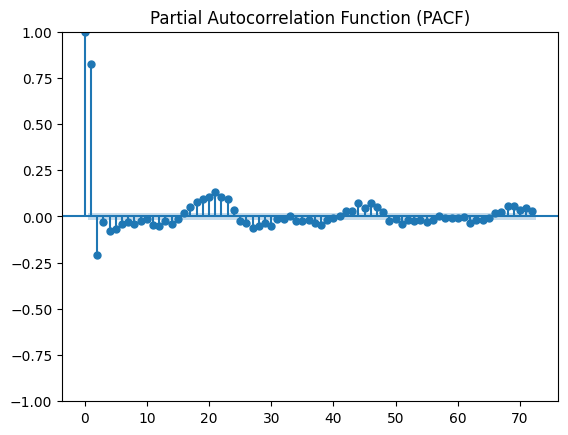

In [29]:
# PACF
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(12,5))

plot_pacf(
    ts,
    lags=72,
    alpha=0.05,
    method="ywm"
)

plt.title("Partial Autocorrelation Function (PACF)")
plt.show()

### Interpretazione del PACF

La Partial Autocorrelation Function mostra un marcato picco al primo lag, seguito da una rapida riduzione delle correlazioni parziali.

Questo risultato suggerisce che il valore corrente della pressione arteriosa dipenda principalmente dall'osservazione immediatamente precedente, mentre l'influenza diretta dei lag successivi risulta molto più contenuta.

La presenza di piccoli picchi in corrispondenza dei lag stagionali è coerente con il comportamento periodico individuato nell'ACF.

### Conclusioni sull'autocorrelazione

L'analisi congiunta di ACF e PACF evidenzia una struttura temporale ben definita della serie.

La forte autocorrelazione ai primi lag indica una significativa dipendenza tra osservazioni consecutive, mentre i picchi ricorrenti osservati ogni 24 ore confermano la presenza di una componente stagionale giornaliera.

Questi risultati, insieme alla decomposizione della serie e ai test di stazionarietà, suggeriscono che un modello stagionale rappresenti una scelta appropriata per la fase di forecasting.

Nella fase successiva verranno quindi implementati e confrontati modelli di previsione della serie temporale, valutandone le prestazioni mediante opportune metriche di errore.

# 9. Suddivisione della serie in Training e Test Set

Per valutare correttamente le prestazioni dei modelli di forecasting, la serie temporale viene suddivisa in un training set, utilizzato per la stima dei modelli, e in un test set, riservato esclusivamente alla valutazione delle previsioni.

Poiché si tratta di una serie temporale, la separazione viene effettuata rispettando rigorosamente l'ordine cronologico delle osservazioni, senza ricorrere a una suddivisione casuale.

A differenza della classica ripartizione 80%-20%, in questo lavoro si è scelto di utilizzare come test set esclusivamente le **ultime 336 osservazioni orarie**, corrispondenti agli ultimi **14 giorni** della serie temporale.

Una suddivisione dell'80%-20% avrebbe infatti prodotto un orizzonte di previsione di circa **73 giorni consecutivi**, particolarmente esteso per modelli di forecasting come ARIMA, SARIMA e Prophet. In un contesto reale tali modelli vengono generalmente impiegati per previsioni a breve o medio termine, mentre orizzonti molto lunghi comportano un progressivo accumulo dell'errore di previsione, rendendo meno significativo il confronto tra i modelli.

La scelta di un test set di 14 giorni rappresenta quindi un compromesso tra rigore metodologico e realismo applicativo: consente infatti di valutare le prestazioni predittive su un intervallo sufficientemente lungo, comprendente **quattordici cicli giornalieri completi**, e allo stesso tempo permette di verificare la capacità dei modelli di riprodurre la stagionalità circadiana individuata nelle analisi esplorative.

In [30]:
# Gli ultimi 14 giorni vengono utilizzati come test set

test_size = 24 * 14   # 336 osservazioni orarie

train = ts.iloc[:-test_size]
test = ts.iloc[-test_size:]

print("Training observations:", len(train))
print("Test observations:", len(test))

print("\nTraining period:")
print(train.index.min(), "→", train.index.max())

print("\nTest period:")
print(test.index.min(), "→", test.index.max())

Training observations: 8424
Test observations: 336

Training period:
2025-01-01 00:00:00 → 2025-12-17 23:00:00

Test period:
2025-12-18 00:00:00 → 2025-12-31 23:00:00


# 10. Scelta dei modelli di forecasting

Le analisi esplorative e i test statistici hanno evidenziato che la serie temporale presenta una struttura ben definita.

In particolare:

- la serie risulta stazionaria secondo i test ADF e KPSS;
- è presente una componente stagionale giornaliera con periodo pari a 24 ore;
- l'analisi ACF e PACF mostra una significativa dipendenza temporale tra osservazioni consecutive.

Sulla base di queste evidenze vengono implementati e confrontati tre modelli di forecasting.

Il primo è un modello **ARIMA**, utilizzato come modello statistico non stagionale di riferimento. Il secondo è un modello **SARIMA**, che estende ARIMA introducendo esplicitamente una componente stagionale con periodo pari a 24 ore, risultando particolarmente coerente con le caratteristiche evidenziate durante l'analisi della serie.

Accanto ai due modelli classici viene considerato anche **Prophet**, un modello per la previsione di serie temporali mediante una formulazione additiva di trend e stagionalità. Sebbene Prophet sia generalmente più indicato per serie caratterizzate da trend complessi, stagionalità multiple e possibili cambiamenti strutturali, mentre la serie analizzata presenta un trend sostanzialmente stabile e una singola stagionalità giornaliera ben definita, esso viene comunque incluso nel confronto al fine di valutare le prestazioni di un approccio differente rispetto ai modelli ARIMA/SARIMA.

Tutti i modelli saranno addestrati sul medesimo training set e valutati sullo stesso test set temporalmente separato. Le prestazioni verranno confrontate mediante le metriche **MAE**, **RMSE** e **MAPE**, così da individuare il modello con la migliore capacità predittiva.

### Selezione del modello ARIMA

Prima di stimare il modello ARIMA è necessario determinarne gli ordini ottimali.

Sebbene l'analisi di ACF e PACF fornisca indicazioni preliminari sulla struttura della serie, la scelta finale dei parametri viene effettuata mediante una procedura automatica di selezione basata sull'AIC (valori più bassi indicano modelli preferibili).

In [31]:
# Installazione
!pip install pmdarima -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 18.9 MB/s eta 0:00:00


In [32]:
# Ricerca automatica dell'ordine ARIMA (senza stagionalità)
from pmdarima import auto_arima

auto_model = auto_arima(
    train,
    seasonal=False,
    stepwise=True,
    suppress_warnings=True,
    trace=True               # stampa i modelli provati, utile da mostrare nel notebook
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=36350.627, Time=16.14 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=105523.659, Time=0.18 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.35 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=94024.287, Time=4.81 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=36311.652, Time=1.73 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=83623.420, Time=10.44 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=36347.551, Time=1.19 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=36274.675, Time=1.37 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=75188.265, Time=5.87 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=36315.526, Time=8.05 sec
 ARIMA(1,0,4)(0,0,0)[0]             : AIC=36210.846, Time=3.48 sec
 ARIMA(0,0,4)(0,0,0)[0]             : AIC=inf, Time=26.41 sec
 ARIMA(2,0,4)(0,0,0)[0]             : AIC=36277.833, Time=8.92 sec
 ARIMA(1,0,5)(0,0,0)[0]             : AIC=inf, Time=13.50 sec
 ARIMA(0,0,5)(0,0,0)[0]         

### Confronto con modelli ARIMA più parsimoniosi

Sebbene la procedura automatica abbia selezionato un modello ARIMA(5,0,4), tale modello presenta numerosi coefficienti non statisticamente significativi.

Per verificare se un modello più semplice possa descrivere adeguatamente la serie temporale, vengono stimati anche alcuni modelli ARIMA di ordine inferiore.

Il confronto verrà effettuato principalmente mediante il criterio AIC e la significatività dei coefficienti stimati, privilegiando, a parità di prestazioni, il modello più parsimonioso.

In [33]:
from statsmodels.tsa.arima.model import ARIMA

orders = [
    (1,0,1),
    (2,0,1),
    (2,0,2),
    (5,0,4)
]

results = {}

for order in orders:

    model = ARIMA(train, order=order)
    fit = model.fit()

    results[order] = fit

    print("="*70)
    print(f"ARIMA{order}")
    print("="*70)
    print(f"AIC: {fit.aic:.2f}")
    print(f"BIC: {fit.bic:.2f}")
    print(fit.summary())

ARIMA(1, 0, 1)
AIC: 35355.83
BIC: 35383.98
                               SARIMAX Results                                
Dep. Variable:            BP_Systolic   No. Observations:                 8424
Model:                 ARIMA(1, 0, 1)   Log Likelihood              -17673.915
Date:                Sat, 18 Jul 2026   AIC                          35355.829
Time:                        16:38:01   BIC                          35383.984
Sample:                    01-01-2025   HQIC                         35365.441
                         - 12-17-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        126.9529      0.111   1147.367      0.000     126.736     127.170
ar.L1          0.7599      0.006    122.523      0.000       0.748       0.772
ma.L1    

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


ARIMA(2, 0, 2)
AIC: 35198.90
BIC: 35241.14
                               SARIMAX Results                                
Dep. Variable:            BP_Systolic   No. Observations:                 8424
Model:                 ARIMA(2, 0, 2)   Log Likelihood              -17593.452
Date:                Sat, 18 Jul 2026   AIC                          35198.903
Time:                        16:38:40   BIC                          35241.136
Sample:                    01-01-2025   HQIC                         35213.322
                         - 12-17-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        126.9526      0.074   1721.293      0.000     126.808     127.097
ar.L1          1.6484      0.019     85.598      0.000       1.611       1.686
ar.L2    

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA(5, 0, 4)
AIC: 35190.42
BIC: 35267.85
                               SARIMAX Results                                
Dep. Variable:            BP_Systolic   No. Observations:                 8424
Model:                 ARIMA(5, 0, 4)   Log Likelihood              -17584.209
Date:                Sat, 18 Jul 2026   AIC                          35190.418
Time:                        16:39:12   BIC                          35267.846
Sample:                    01-01-2025   HQIC                         35216.852
                         - 12-17-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        126.9656      0.073   1733.954      0.000     126.822     127.109
ar.L1          0.4701      0.245      1.920      0.055      -0.010       0.950
ar.L2    

In [34]:
comparison = []

for order, fit in results.items():

    comparison.append({
        "Model": f"ARIMA{order}",
        "AIC": fit.aic,
        "BIC": fit.bic
    })

comparison = (
    pd.DataFrame(comparison)
      .sort_values("AIC")
      .reset_index(drop=True)
)

comparison

,Model,AIC,BIC
0,"ARIMA(5, 0, 4)",35190.418310,35267.845551
1,"ARIMA(2, 0, 2)",35198.903142,35241.136182
2,"ARIMA(2, 0, 1)",35256.276865,35291.471065
3,"ARIMA(1, 0, 1)",35355.829016,35383.984376


### Scelta del modello ARIMA (2, 0, 2)

L'algoritmo **Auto ARIMA** ha individuato come modello ottimale **ARIMA(5,0,4)**, in quanto caratterizzato dal valore minimo del criterio di Akaike (AIC).

Tuttavia, l'analisi della significatività statistica dei parametri ha evidenziato che diversi coefficienti autoregressivi e a media mobile presentano **p-value elevati**, risultando quindi **non statisticamente significativi**. Ciò suggerisce che il modello sia eccessivamente complesso rispetto alla struttura della serie temporale e che alcuni parametri non contribuiscano in modo significativo alla spiegazione dei dati.

Sono stati quindi confrontati anche modelli più semplici (**ARIMA(1,0,1)**, **ARIMA(2,0,1)** e **ARIMA(2,0,2)**), valutandone i criteri informativi (AIC e BIC) e la significatività dei coefficienti stimati.

Il modello **ARIMA(1,0,1)** è stato escluso poiché, pur presentando coefficienti statisticamente significativi, mostra valori di **AIC** e **BIC** sensibilmente peggiori rispetto agli altri modelli considerati.

Anche **ARIMA(2,0,1)** presenta coefficienti tutti significativi, ma risulta meno performante di **ARIMA(2,0,2)**, con valori di **AIC** e **BIC** più elevati.

Infine, sebbene **ARIMA(5,0,4)** presenti il valore minimo di **AIC**, il miglioramento rispetto ad **ARIMA(2,0,2)** è modesto (circa 8 punti di AIC) ed è ottenuto al prezzo di un modello molto più complesso, caratterizzato da diversi coefficienti non statisticamente significativi.

Per tali motivi è stato scelto **ARIMA(2,0,2)**, che rappresenta il miglior compromesso tra qualità dell'adattamento, significatività dei parametri e semplicità del modello, nel rispetto del **principio di parsimonia**.

## Selezione del modello SARIMA

Poiché le analisi esplorative, la decomposizione e l'ACF hanno evidenziato una stagionalità giornaliera, viene considerato un modello SARIMA con periodo stagionale pari a **24 ore**.

La configurazione generale del modello è indicata come:

\[
SARIMA(p,d,q)(P,D,Q)_{24}
\]

dove `(p,d,q)` rappresenta la componente non stagionale, mentre `(P,D,Q)` descrive la struttura stagionale.

I test ADF e KPSS hanno indicato che la serie è già stazionaria. Pertanto, nella procedura di selezione vengono inizialmente fissati a zero sia il parametro di differenziazione ordinaria `d` sia quello di differenziazione stagionale `D`.

La ricerca viene effettuata esclusivamente sul training set.  
### Identificazione preliminare dell'ordine SARIMA dai grafici

Prima di ricorrere alla ricerca automatica degli ordini tramite `auto_arima`, è possibile
ricavare una stima preliminare dei parametri del modello SARIMA(p,d,q)(P,D,Q)s
direttamente dall'interpretazione dei grafici prodotti nelle sezioni precedenti
(decomposizione, ADF/KPSS, ACF/PACF).

**Parte non stagionale (p, d, q)**

- **d** (grado di differenziazione): i test ADF e KPSS, applicati nella sezione 7,
  concordano nell'indicare che la serie è già stazionaria. Non è quindi necessaria
  alcuna differenziazione: **d = 0**.

- **p** (ordine autoregressivo): la PACF (sezione 8) mostra un marcato picco al primo
  lag, seguito da una rapida riduzione delle correlazioni parziali nei lag successivi.
  Questo comportamento, tipico di un processo autoregressivo di ordine basso, suggerisce
  **p = 1**.

- **q** (ordine a media mobile): la ACF mostra un decadimento più graduale rispetto al
  taglio netto osservato nella PACF, caratteristica compatibile con la presenza di una
  componente a media mobile. Un valore iniziale di **q = 1** rappresenta un punto di
  partenza ragionevole, pur essendo il parametro più incerto da stimare a occhio.

**Parte stagionale (P, D, Q, s)**

- **s** (periodo stagionale): non è una stima, ma un valore noto con certezza. La
  decomposizione (sezione 6) e i picchi ricorrenti dell'ACF ai lag 24, 48 e 72 (sezione 8)
  confermano inequivocabilmente un ciclo stagionale di **s = 24** ore, coerente con il
  pattern circadiano della pressione arteriosa.

- **D** (differenziazione stagionale): poiché ADF e KPSS indicano stazionarietà anche
  a livello del pattern giornaliero (nessun trend, ciclo stabile e ripetuto nel tempo),
  si assume **D = 0**.

- **P, Q** (componenti autoregressiva e a media mobile stagionali): l'ampiezza dei picchi
  ACF/PACF osservata in corrispondenza dei lag stagionali (24, 48, 72) è marcata al primo
  picco stagionale e decresce nei successivi, suggerendo **P = 1, Q = 1**.

**Ordine risultante dalla lettura manuale dei grafici**

$$\text{SARIMA}(1,0,1)(1,0,1)_{24}$$

Questa stima verrà confrontata, nella sezione successiva, con l'ordine individuato mediante la procedura di ricerca automatica `auto_arima`, al fine di verificare la coerenza tra l'interpretazione grafica e l'ottimizzazione basata sul criterio di Akaike (AIC).

In [35]:
from pmdarima import auto_arima

auto_sarima = auto_arima(
    train,
    seasonal=True,
    m=24,

    # La serie è risultata stazionaria
    d=0,
    D=0,

    # Ricerca controllata per limitare i tempi di calcolo
    start_p=0,
    start_q=0,
    max_p=3,
    max_q=3,

    start_P=0,
    start_Q=0,
    max_P=1,
    max_Q=1,

    stepwise=True,
    trace=True,
    suppress_warnings=True,
    error_action="ignore",

    information_criterion="aic"
)

print("Ordine non stagionale selezionato:", auto_sarima.order)
print("Ordine stagionale selezionato:", auto_sarima.seasonal_order)
print("AIC:", auto_sarima.aic())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[24] intercept   : AIC=45419.701, Time=0.15 sec
 ARIMA(1,0,0)(1,0,0)[24] intercept   : AIC=inf, Time=70.71 sec
 ARIMA(0,0,1)(0,0,1)[24] intercept   : AIC=38429.877, Time=13.61 sec
 ARIMA(0,0,0)(0,0,0)[24]             : AIC=105523.659, Time=0.37 sec
 ARIMA(0,0,1)(0,0,0)[24] intercept   : AIC=39200.124, Time=1.89 sec
 ARIMA(0,0,1)(1,0,1)[24] intercept   : AIC=38354.455, Time=102.57 sec
 ARIMA(0,0,1)(1,0,0)[24] intercept   : AIC=47686.252, Time=65.22 sec
 ARIMA(0,0,0)(1,0,1)[24] intercept   : AIC=44104.367, Time=69.49 sec
 ARIMA(1,0,1)(1,0,1)[24] intercept   : AIC=inf, Time=84.88 sec
 ARIMA(0,0,2)(1,0,1)[24] intercept   : AIC=inf, Time=102.71 sec
 ARIMA(1,0,0)(1,0,1)[24] intercept   : AIC=inf, Time=56.11 sec
 ARIMA(1,0,2)(1,0,1)[24] intercept   : AIC=inf, Time=106.45 sec
 ARIMA(0,0,1)(1,0,1)[24]             : AIC=41797.562, Time=31.74 sec

Best model:  ARIMA(0,0,1)(1,0,1)[24] intercept
Total fit time: 705.915 seconds
Ordine no

In [36]:
# verifica significatività dei coefficenti
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima = SARIMAX(
    train,
    order=(0,0,1),
    seasonal_order=(1,0,1,24)
)

sarima_fit = sarima.fit()

print(sarima_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                                     SARIMAX Results                                      
Dep. Variable:                        BP_Systolic   No. Observations:                 8424
Model:             SARIMAX(0, 0, 1)x(1, 0, 1, 24)   Log Likelihood              -20894.781
Date:                            Sat, 18 Jul 2026   AIC                          41797.562
Time:                                    16:51:30   BIC                          41825.717
Sample:                                01-01-2025   HQIC                         41807.174
                                     - 12-17-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.9014      0.003    318.476      0.000       0.896       0.907
ar.S.L24       0.9998      0.000   

### Scelta del modello SARIMA

L'algoritmo Auto ARIMA con componente stagionale ha selezionato il modello **SARIMA(0,0,1)(1,0,1)24**.
La parte stagionale coincide esattamente con la stima manuale, confermando l'affidabilità della lettura dei grafici; la parte non stagionale differisce lievemente (q=1 invece di p=1,q=1), scarto plausibile dato che AR e MA di ordine basso possono spiegare pattern simili nei dati.

L'analisi dei coefficienti mostra che tutti i parametri risultano statisticamente significativi (p-value < 0.05), indicando una corretta stima della componente autoregressiva e stagionale.

Tuttavia, il modello presenta un valore di **AIC pari a 41797.56**, nettamente superiore rispetto al valore ottenuto dal modello **ARIMA(2,0,2)** (AIC = 35198.90).

Pertanto, nonostante la presenza di una componente stagionale giornaliera evidenziata durante l'analisi esplorativa, l'introduzione della struttura stagionale non comporta un miglioramento dell'adattamento del modello. Al contrario, il modello ARIMA descrive la serie in modo più efficace. Quindi, aggiungere la componente stagionale del SARIMA non aggiunge informazione, ma introduce parametri inutili.
Esiste una stagionalità, ma non è sufficientemente forte da giustificare un modello stagionale.

Il confronto basato sul solo AIC suggerirebbe quindi di preferire ARIMA a SARIMA. Tuttavia, l'AIC è un criterio di adattamento in-sample e non garantisce necessariamente le migliori prestazioni di previsione out-of-sample: la scelta definitiva verrà effettuata nella sezione conclusiva, sulla base delle metriche di errore calcolate sul test set.

## Addestramento dei modelli selezionati

Dopo aver individuato le configurazioni definitive, i modelli ARIMA e SARIMA vengono stimati sul medesimo training set.

Il modello ARIMA adottato è **ARIMA(2,0,2)**, selezionato sulla base del confronto tra criteri informativi, significatività dei coefficienti e principio di parsimonia.

Il modello stagionale adottato è **SARIMA(0,0,1)(1,0,1)₍₂₄₎**, individuato mediante ricerca automatica con periodicità giornaliera pari a 24 ore.

Il test set non viene utilizzato durante l'addestramento e rimane riservato esclusivamente alla valutazione finale delle capacità predittive.

## Addestramento ARIMA

In [37]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(
    train,
    order=(2, 0, 2)
)

arima_fit = arima_model.fit()

print(arima_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:            BP_Systolic   No. Observations:                 8424
Model:                 ARIMA(2, 0, 2)   Log Likelihood              -17593.452
Date:                Sat, 18 Jul 2026   AIC                          35198.903
Time:                        16:51:46   BIC                          35241.136
Sample:                    01-01-2025   HQIC                         35213.322
                         - 12-17-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        126.9526      0.074   1721.293      0.000     126.808     127.097
ar.L1          1.6484      0.019     85.598      0.000       1.611       1.686
ar.L2         -0.7152      0.014    -52.409      0.0

## Addestramento SARIMA

In [38]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train,
    order=(0, 0, 1),
    seasonal_order=(1, 0, 1, 24)
)

sarima_fit = sarima_model.fit()

print(sarima_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                                     SARIMAX Results                                      
Dep. Variable:                        BP_Systolic   No. Observations:                 8424
Model:             SARIMAX(0, 0, 1)x(1, 0, 1, 24)   Log Likelihood              -20894.781
Date:                            Sat, 18 Jul 2026   AIC                          41797.562
Time:                                    16:52:16   BIC                          41825.717
Sample:                                01-01-2025   HQIC                         41807.174
                                     - 12-17-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.9014      0.003    318.476      0.000       0.896       0.907
ar.S.L24       0.9998      0.000   

## Previsioni ARIMA e SARIMA

In [39]:
# Previsioni sul test set

forecast_arima = arima_fit.forecast(steps=len(test))
forecast_sarima = sarima_fit.forecast(steps=len(test))

print("Previsioni ARIMA:", len(forecast_arima))
print("Previsioni SARIMA:", len(forecast_sarima))

Previsioni ARIMA: 336
Previsioni SARIMA: 336


## Configurazione del modello Prophet

Oltre ai modelli ARIMA e SARIMA, viene considerato anche il modello **Prophet** per il forecasting di serie temporali.

Prophet è particolarmente indicato per serie caratterizzate da trend di lungo periodo, molteplici componenti stagionali, festività ed eventuali cambiamenti strutturali.

Nel presente lavoro il suo utilizzo è principalmente finalizzato al confronto con i modelli classici. Infatti, la serie analizzata è già risultata stazionaria e non presenta trend di lungo periodo, caratteristiche che rendono generalmente più appropriati modelli appartenenti alla famiglia ARIMA.

Tuttavia, l'inclusione di Prophet permette di confrontare approcci di modellazione differenti utilizzando le medesime metriche di valutazione.

In [40]:
# preparazione dei dati
train_prophet = train.reset_index()

train_prophet.columns = ["ds", "y"]

In [41]:
!pip install prophet -q

In [42]:
# modello
from prophet import Prophet

prophet = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=True
)

prophet.fit(train_prophet)

In [43]:
# preparazione del test
future = test.reset_index()

future.columns = ["ds", "y"]

future = future[["ds"]]

In [44]:
# forecast
forecast_prophet = prophet.predict(future)

forecast_prophet.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,daily_lower,daily_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2025-12-18 00:00:00,126.903594,120.579777,127.380104,126.903594,126.903594,-2.987148,-2.987148,-2.987148,-2.987148,-2.987148,-2.987148,0.0,0.0,0.0,123.916446
1,2025-12-18 01:00:00,126.903706,119.646206,126.482034,126.903706,126.903706,-3.803482,-3.803482,-3.803482,-3.803482,-3.803482,-3.803482,0.0,0.0,0.0,123.100224
2,2025-12-18 02:00:00,126.903818,119.431097,125.723277,126.903818,126.903818,-4.302329,-4.302329,-4.302329,-4.302329,-4.302329,-4.302329,0.0,0.0,0.0,122.601490
3,2025-12-18 03:00:00,126.903931,119.314173,125.970315,126.903931,126.903931,-4.318700,-4.318700,-4.318700,-4.318700,-4.318700,-4.318700,0.0,0.0,0.0,122.585230
4,2025-12-18 04:00:00,126.904043,119.908200,126.600378,126.904043,126.904043,-3.650061,-3.650061,-3.650061,-3.650061,-3.650061,-3.650061,0.0,0.0,0.0,123.253982


In [45]:
forecast_prophet[["ds","yhat"]]

,ds,yhat
0,2025-12-18 00:00:00,123.916446
1,2025-12-18 01:00:00,123.100224
2,2025-12-18 02:00:00,122.601490
3,2025-12-18 03:00:00,122.585230
4,2025-12-18 04:00:00,123.253982
...,...,...
331,2025-12-31 19:00:00,127.578338
332,2025-12-31 20:00:00,127.434666
333,2025-12-31 21:00:00,126.924827
334,2025-12-31 22:00:00,126.041023


In [46]:
forecast_prophet_values = forecast_prophet["yhat"].values

## Valutazione dei modelli

Per confrontare le prestazioni dei modelli vengono utilizzate tre metriche comunemente impiegate nei problemi di forecasting:

- **MAE (Mean Absolute Error)**: errore assoluto medio tra valori osservati e previsti.
- **RMSE (Root Mean Squared Error)**: misura l'errore quadratico medio, penalizzando maggiormente gli errori più elevati.
- **MAPE (Mean Absolute Percentage Error)**: esprime l'errore medio in termini percentuali.

Valori inferiori di tali metriche indicano prestazioni predittive migliori.

In [47]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

import numpy as np
import pandas as pd

comparison = pd.DataFrame({

    "Model":[
        "ARIMA(2,0,2)",
        "SARIMA(0,0,1)(1,0,1,24)",
        "Prophet"
    ],

    "MAE":[
        mean_absolute_error(test, forecast_arima),
        mean_absolute_error(test, forecast_sarima),
        mean_absolute_error(test, forecast_prophet_values)
    ],

    "RMSE":[
        np.sqrt(mean_squared_error(test, forecast_arima)),
        np.sqrt(mean_squared_error(test, forecast_sarima)),
        np.sqrt(mean_squared_error(test, forecast_prophet_values))
    ],
    "MAPE (%)": [
    mean_absolute_percentage_error(test, forecast_arima) * 100,
    mean_absolute_percentage_error(test, forecast_sarima) * 100,
    mean_absolute_percentage_error(test, forecast_prophet_values) * 100
]
})


comparison.sort_values("RMSE")

,Model,MAE,RMSE,MAPE (%)
2,Prophet,1.947900,2.443862,1.538264
1,"SARIMA(0,0,1)(1,0,1,24)",2.167643,2.676107,1.713552
0,"ARIMA(2,0,2)",2.784085,3.341543,2.201027


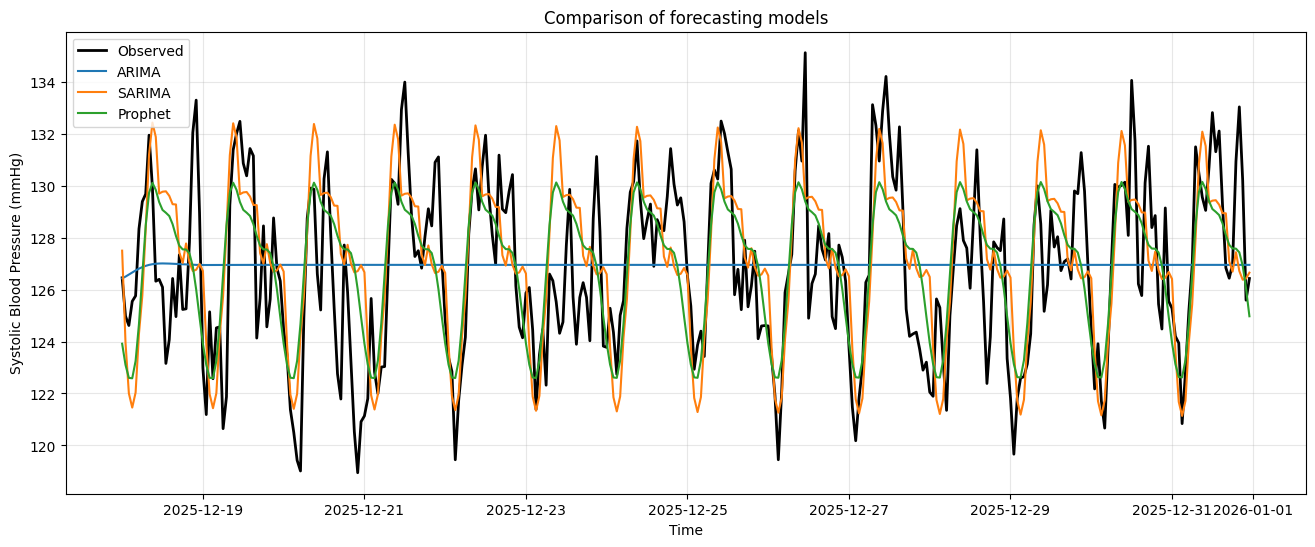

In [48]:
# grafico
plt.figure(figsize=(16,6))

plt.plot(test.index,
         test,
         color="black",
         linewidth=2,
         label="Observed")

plt.plot(test.index,
         forecast_arima,
         label="ARIMA")

plt.plot(test.index,
         forecast_sarima,
         label="SARIMA")

plt.plot(test.index,
         forecast_prophet_values,
         label="Prophet")

plt.title("Comparison of forecasting models")

plt.xlabel("Time")

plt.ylabel("Systolic Blood Pressure (mmHg)")

plt.grid(alpha=0.3)

plt.legend()

plt.show()

In [49]:
# controllo per capire se ARIMA genera previsioni correttamente dato che risulta quasi piatto
forecast_arima.head()

,predicted_mean
2025-12-18 00:00:00,126.433582
2025-12-18 01:00:00,126.500987
2025-12-18 02:00:00,126.579341
2025-12-18 03:00:00,126.660297
2025-12-18 04:00:00,126.737708


In [50]:
forecast_sarima.head()

,predicted_mean
2025-12-18 00:00:00,127.499992
2025-12-18 01:00:00,123.958843
2025-12-18 02:00:00,122.003982
2025-12-18 03:00:00,121.457767
2025-12-18 04:00:00,122.036243


## 11. Confronto finale e scelta del modello

### Perché ARIMA produce previsioni quasi piatte

Il modello ARIMA(2,0,2), pur avendo ottenuto il valore di AIC più basso in fase di
stima (35.198,90), genera sul test set una previsione che converge rapidamente e in
modo monotono verso un valore pressoché costante, vicino alla media incondizionata
della serie (~127 mmHg).

Questo comportamento non è un errore di implementazione, ma una conseguenza diretta
della struttura del modello. ARIMA non contiene alcuna componente stagionale: la sua
previsione a un orizzonte h dipende esclusivamente dagli ultimi valori osservati e dai
residui recenti al momento in cui inizia la previsione. Con l'aumentare di h, questa
dipendenza si attenua progressivamente secondo la dinamica autoregressiva del modello,
finché la previsione non converge al valore medio della serie. Poiché il test set copre
336 osservazioni consecutive (14 giorni) previste senza mai osservare dati reali
intermedi, l'orizzonte di previsione è ampiamente superiore alla memoria effettiva del
modello: ARIMA "dimentica" rapidamente il momento della giornata e non ha alcun
meccanismo per sapere che, ad esempio, siamo nelle ore notturne piuttosto che in quelle
mattutine.

SARIMA, al contrario, include un termine autoregressivo stagionale con coefficiente
ar.S.L24 ≈ 0,9998, praticamente prossimo a un'unità stagionale: questo lega
esplicitamente la previsione al valore osservato 24 ore prima, permettendo al modello
di continuare a riprodurre il ciclo circadiano anche a orizzonti di previsione lunghi.

### Perché Prophet risulta il modello migliore, senza contraddire l'analisi teorica

Nella sezione 10 è stato osservato che Prophet è generalmente più indicato per serie
caratterizzate da trend complessi, stagionalità multiple, festività e cambiamenti
strutturali, caratteristiche assenti nella serie analizzata. Il fatto che Prophet
risulti il modello con le metriche di errore migliori (MAE, RMSE, MAPE più bassi) non
contraddice questa osservazione, ma va interpretato correttamente.

Nella configurazione adottata, con `yearly_seasonality=False` e `weekly_seasonality=False`,
Prophet stima essenzialmente due componenti: un trend (di fatto quasi costante, coerente
con l'assenza di trend evidenziata nella decomposizione) e una stagionalità giornaliera
modellata tramite serie di Fourier. Questa componente stagionale è una funzione
deterministica e periodica del momento della giornata, che **non si attenua** con
l'aumentare dell'orizzonte di previsione, a differenza della componente autoregressiva
di ARIMA e, in misura minore, di SARIMA.

Poiché la serie analizzata presenta un trend sostanzialmente piatto e un'unica
stagionalità giornaliera ben definita e regolare, il compito di previsione si riduce,
nella sostanza, alla riproduzione del ciclo circadiano medio già individuato nella
sezione 4 (profilo giornaliero) e nella sezione 6 (componente stagionale della
decomposizione). Questo scenario rappresenta il caso più favorevole possibile per un
modello a stagionalità deterministica esplicita come Prophet, che qui non sfrutta le
sue funzionalità più avanzate, ma applica comunque con efficacia il principio di base
(trend + stagionalità) alla struttura particolarmente pulita e regolare di questa serie
sintetica.

### Riconciliazione tra AIC e metriche di errore sul test set

Il confronto tra i modelli evidenzia un'apparente contraddizione: ARIMA(2,0,2) presenta
il miglior AIC in fase di stima, ma le peggiori prestazioni di previsione sul test set
(RMSE = 3,34 contro 2,68 di SARIMA e 2,44 di Prophet).

Questa discrepanza si spiega considerando che l'AIC è un criterio di adattamento
**in-sample**: valuta quanto bene il modello spiega i dati già osservati durante la
stima, un compito che si avvicina concettualmente a una previsione a un solo passo
condizionata sui valori osservati. Il test set richiede invece una previsione
**multi-step** di 336 ore consecutive, senza alcun aggiornamento con osservazioni
reali intermedie: un compito radicalmente diverso, in cui la capacità di un modello di
rappresentare esplicitamente pattern deterministici di lungo periodo (come la
stagionalità giornaliera) diventa determinante.

Questo risultato evidenzia un principio metodologico rilevante: la selezione di un
modello basata unicamente su criteri di adattamento in-sample (AIC, BIC) non garantisce
le migliori prestazioni di forecasting out-of-sample, in particolare quando la serie
presenta una componente stagionale rilevante rispetto all'orizzonte di previsione
richiesto.

### Modello selezionato

Sulla base delle metriche calcolate sul test set, temporalmente separato e mai
utilizzato in fase di stima, il modello con le prestazioni predittive migliori è
**Prophet** (MAE = 1,95, RMSE = 2,44, MAPE = 1,54%), seguito da
**SARIMA(0,0,1)(1,0,1)₍₂₄₎** (MAE = 2,17, RMSE = 2,68, MAPE = 1,71%) e da
**ARIMA(2,0,2)** (MAE = 2,78, RMSE = 3,34, MAPE = 2,20%).

Coerentemente con il criterio di selezione basato sulle prestazioni predittive out-of- sample, **Prophet** viene scelto come modello finale da utilizzare nella Fase 3
(applicazione Streamlit). Questa scelta risulta motivata sia dall'accuratezza superiore sul test set, sia da considerazioni pratiche legate al deployment: Prophet offre una maggiore flessibilità nella gestione delle serie temporali e si integra facilmente in un'applicazione interattiva, consentendo un rapido riaddestramento sui dati caricati dall'utente.

In [51]:
# Salvataggio del modello Prophet addestrato e validato in Fase 2.
# NOTA: questo file NON viene ricaricato nell'app Streamlit (Fase 3), poiché è stato
# addestrato su un singolo paziente con uno split train/test fisso, utile solo per
# la validazione. L'app riaddestra invece Prophet, con la stessa configurazione
# (stagionalità giornaliera esplicita), direttamente sui dati caricati dall'utente,
# per garantire compatibilità con qualunque CSV conforme alla struttura del dataset.
# Il file viene conservato come artefatto della Fase 2, a scopo di riproducibilità.
from prophet.serialize import model_to_json

with open("prophet_model.json", "w") as f:
    f.write(model_to_json(prophet))

print("Modello Prophet salvato in 'prophet_model.json'")

Modello Prophet salvato in 'prophet_model.json'
